# 02 - Hypothesis Space

## What explanations are possible?

Notebook 00 introduced the workshop frame:

$$
\boxed{\mathcal{H}} + \mathcal{D} + \mathcal{O} \rightarrow s.
$$

Notebook 01 unpacked $\mathcal{D}$: finite evidence has representation, noise, coverage, geometry, design choices, and gaps. This notebook now turns to $\mathcal{H}$. It keeps one collected dataset fixed and asks: given this evidence, what explanations is the learner even allowed to consider?

A **hypothesis** is one possible rule for turning inputs into predictions. In this notebook, a hypothesis is a function such as $h(x)$ that maps an input $x$ to a predicted output $\hat{y}(x)$. A **hypothesis space** is the set of functions the learner can choose from.

The through-line is:

1. hold $\mathcal{D}$ fixed so changes in behaviour come from $\mathcal{H}$;
2. build $\mathcal{H}$ from reusable feature shapes and allowable parameters;
3. separate the hypothesis space from one selected parameter vector;
4. enlarge $\mathcal{H}$ and watch expressiveness become fragility;
5. show that finite $\mathcal{D}$ may leave several hypotheses defensible;
6. separate the functions in $\mathcal{H}$ from the coordinates used to search them;
7. hand the final selection problem to Notebook 03, where $\mathcal{O}$ enters.

We will use simple regression examples so the moving parts stay visible: the data $\mathcal{D}$, a feature matrix $\Phi$, a parameter vector $\theta$, and predictions $\Phi\theta$. The point is broader than this notation: learning can only select from the explanations made available by the chosen hypothesis space.


## Learning objectives

By the end of this notebook, you should be able to:

1. define a hypothesis space as a set of possible functions, not one fitted model;
2. explain how feature columns define what shapes can be built;
3. distinguish changing one selected parameter vector from changing the hypothesis space;
4. explain how increasing expressiveness can reduce underfitting while increasing fragility;
5. distinguish the function space from the coordinates used to represent it.


## Session arc

This notebook follows one semantic wave:

1. **Abstract:** $\mathcal{H}$ is the set of explanations the learner may consider.
2. **Concrete:** polynomial feature columns define curve shapes.
3. **Inspect:** manually change parameters, then change polynomial degree.
4. **Diagnose:** identify underfitting, fragile overfitting, and unsupported behaviour.
5. **Repack:** the optimizer can only choose from behaviours made available by $\mathcal{H}$.

Use this question throughout:

> Did we change the selected function, or did we change the space of functions that could be selected?


In [1]:
# Environment setup. The notebook is designed to run locally and in Colab.
import os
import subprocess
import sys
import tempfile
from pathlib import Path

os.environ.setdefault(
    "MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "nextgen2026-matplotlib")
)

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

if "google.colab" in sys.modules:
    repo_dir = Path("/content/nextgen2026-mlai-workshops")
    if not repo_dir.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                "workshop1",
                "https://github.com/nextgenerationgraduatesprogram/nextgen2026-mlai-workshops.git",
                str(repo_dir),
            ],
            check=True,
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", str(repo_dir)], check=True)
    sys.path.insert(0, str(repo_dir / "src"))
else:
    for possible_root in (Path.cwd(), Path.cwd().parent):
        possible_src = possible_root / "src"
        if (possible_src / "nextgen2026_mlai_workshops").exists():
            sys.path.insert(0, str(possible_src))
            break

from nextgen2026_mlai_workshops import data, metrics, models, plots

np.set_printoptions(precision=3, suppress=True)


def format_value(value, digits=4):
    """Format numeric values for compact text summaries."""
    if isinstance(value, (float, np.floating)):
        value = float(value)
        if value == 0.0:
            return "0"
        if abs(value) < 10 ** (-digits) or abs(value) >= 10_000:
            return f"{value:.2e}"
        return f"{value:.{digits}f}"
    if isinstance(value, (int, np.integer)):
        return str(int(value))
    return str(value)


def print_rows(rows, digits=4, title=None):
    """Print a list of dictionaries as readable summary lines."""
    if title:
        print(title)
    for index, row in enumerate(rows, start=1):
        parts = [f"{key}={format_value(value, digits=digits)}" for key, value in row.items()]
        print(f"{index:02d}. " + ", ".join(parts))


def show_fig(fig):
    display(fig)
    plt.close(fig)


## Hold $\mathcal{D}$ Fixed

The first move is to freeze the evidence term from the workshop frame. Define one collected dataset,

$$
\mathcal{D}=\{(x_i,y_i)\}_{i=1}^{n}.
$$

For the first pass, treat this dataset as fixed evidence. If two fitted curves behave differently, the difference should come from the hypothesis-space choices rather than from a different sample. This is the main handoff from Notebook 01: the limits of $\mathcal{D}$ are still present, but we are no longer changing them.

As you inspect the plot, ask what a reasonable explanation would need to do between the observed points, not just at them. That question cannot be answered by $\mathcal{D}$ alone; it depends on the hypotheses we permit next. Later, change the data settings and rerun the notebook to see which observations depended on this particular $\mathcal{D}$.


In [2]:
# Data-space controls. Leave these fixed for the first pass.
n_samples = 20
noise_std = 0.20
seed = 2026
sampling = "uniform"  # "uniform", "clustered", or "partial_domain"

x_observed, y_observed = data.make_regression_data(
    n=n_samples,
    noise_std=noise_std,
    seed=seed,
    sampling=sampling,
)

print_rows(
    [
        {
            "n_samples": n_samples,
            "noise_std": noise_std,
            "sampling": sampling,
            "x_min": np.min(x_observed),
            "x_max": np.max(x_observed),
        }
    ],
    title="Fixed evidence for this notebook",
)


Fixed evidence for this notebook
01. n_samples=20, noise_std=0.2000, sampling=uniform, x_min=0.1774, x_max=0.9670


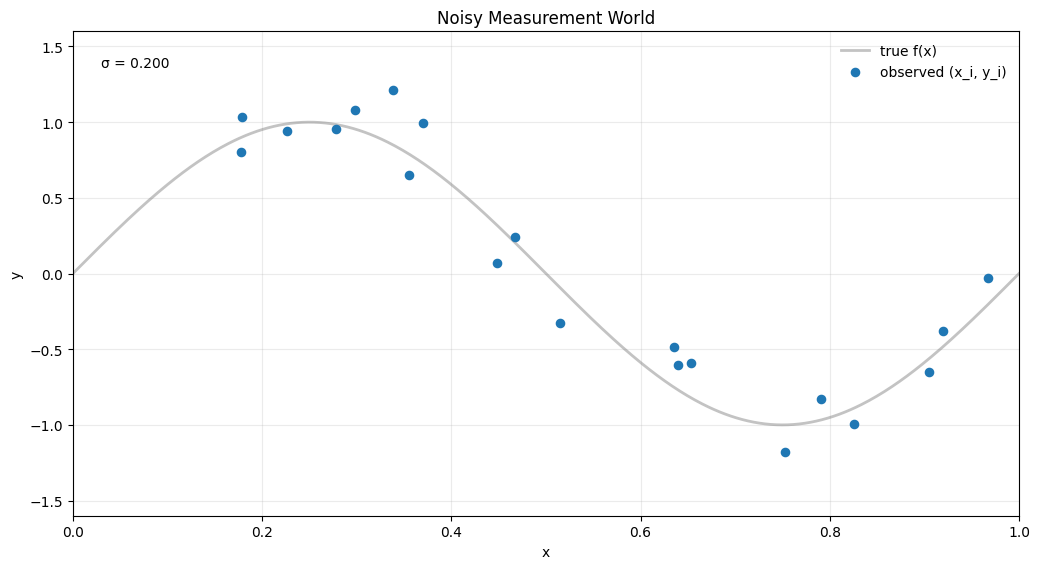

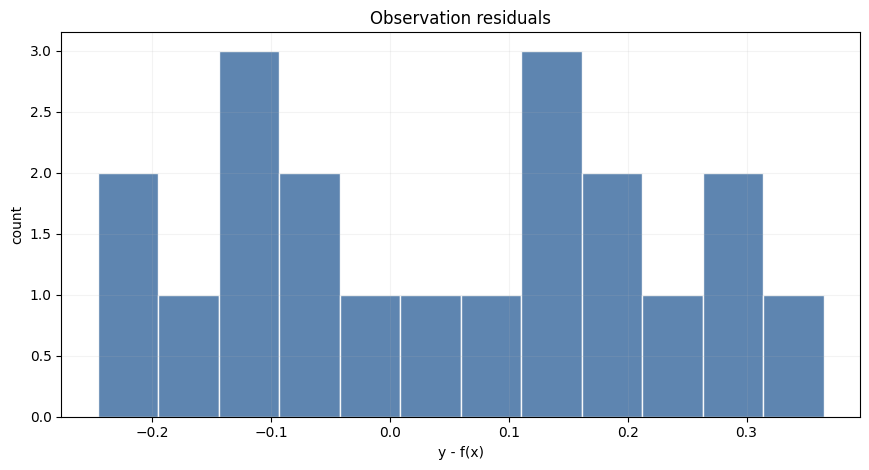

In [3]:
# Visualise the fixed evidence.
fig = plots.plot_measurement_world(x_observed, y_observed, noise_std=noise_std)
show_fig(fig)

residual_fig = plots.plot_residual_histogram(x_observed, y_observed)
show_fig(residual_fig)


## Define $\mathcal{H}$: Candidate Explanations

Notebook 01 asked what evidence was available. A hypothesis space asks a different question: what forms of explanation are allowed before fitting begins?

That choice imposes assumptions. If we choose straight lines, we assume the response can be explained well enough by a constant rate of change. If we choose low-degree polynomials, we allow smooth bends but rule out sharp local structure. If we choose periodic features, monotone functions, splines, trees, or neural networks, we build in different assumptions about shape, locality, smoothness, interactions, and extrapolation.

In this notebook, a **model class** is the parameterised recipe for producing predictions. For fixed-feature regression, the recipe is

$$
h_\theta(x)=\theta^\top\phi(x).
$$

The recipe has two parts:

1. the feature map $\phi$, which defines reusable shapes; and
2. the allowable parameter values $\theta\in\Theta$, which mix those shapes into one prediction rule.

For a single input $x$, write the feature shapes as

$$
\phi(x) = [\phi_0(x), \phi_1(x), \ldots, \phi_d(x)].
$$

For all observed inputs in $\mathcal{D}$, stack those feature vectors into a matrix $\Phi$. A parameter vector $\theta$ supplies the mixing weights, and the training predictions are

$$
\hat{y} = \Phi\theta.
$$

A parameter vector is not the hypothesis by itself. It selects one function $h_\theta$. The **hypothesis space** is the collection of all functions selected by allowable parameter values:

$$
\mathcal{H} = \{h_\theta:x \mapsto \theta^\top \phi(x) \mid \theta \in \Theta\}.
$$

Choosing $\mathcal{H}$ creates an **inductive bias**: a preference built into the learner before fitting. In scientific terms, this is where we encode assumptions about what the data-generating process might plausibly look like: straight, smooth, low-degree, periodic, saturating, monotone, local, or something else.

This is the first hypothesis-space diagnostic: before fitting, ask what assumptions are already baked into $\mathcal{H}$. Fitting comes later. First choose the space of possible explanations; then an objective or algorithm selects one member of that space.


## Feature Columns Define What Can Be Built

The next step makes that construction concrete. Begin with polynomial feature columns:

$$
\phi_d(x) = [1, x, x^2, \ldots, x^d].
$$

This defines the degree-$d$ polynomial hypothesis space:

$$
\mathcal{H}_d = \{x \mapsto \theta^\top\phi_d(x) \mid \theta \in \mathbb{R}^{d+1}\}.
$$

Each column is a shape over the input range. Each entry of $\theta$ says how strongly to mix one column into the final curve. If a useful shape cannot be built from these columns, fitting can only choose the closest explanation this representation makes available.

This is the second hypothesis-space diagnostic: inspect the feature columns as shapes, not just as algebra. The word *basis* is used when the columns are linearly independent and span the function class being discussed. More generally, people may call the collection a feature dictionary.


### Before running: read features as shapes

The next cell builds a polynomial feature matrix $\Phi$. Do not read $\Phi$ only as a table of numbers. Read each column as a reusable shape that the model can mix into a curve.

Before running, predict which shapes are available when the degree is 0, 1, 2, 3, and 4.



First rows of Phi, with one chosen theta
01. x=0.1774, x^0=1.0000, x^1=0.1774, x^2=0.0315, x^3=0.0056, x^4=0.0010, Phi@theta=0.1805
02. x=0.1789, x^0=1.0000, x^1=0.1789, x^2=0.0320, x^3=0.0057, x^4=0.0010, Phi@theta=0.1802
03. x=0.2263, x^0=1.0000, x^1=0.2263, x^2=0.0512, x^3=0.0116, x^4=0.0026, Phi@theta=0.1736
04. x=0.2779, x^0=1.0000, x^1=0.2779, x^2=0.0772, x^3=0.0215, x^4=0.0060, Phi@theta=0.1712
05. x=0.2983, x^0=1.0000, x^1=0.2983, x^2=0.0890, x^3=0.0265, x^4=0.0079, Phi@theta=0.1715
Mixing weights theta
01. feature_column=x^0, theta=0.2500
02. feature_column=x^1, theta=-0.6000
03. feature_column=x^2, theta=1.2000
04. feature_column=x^3, theta=0
05. feature_column=x^4, theta=-0.8000


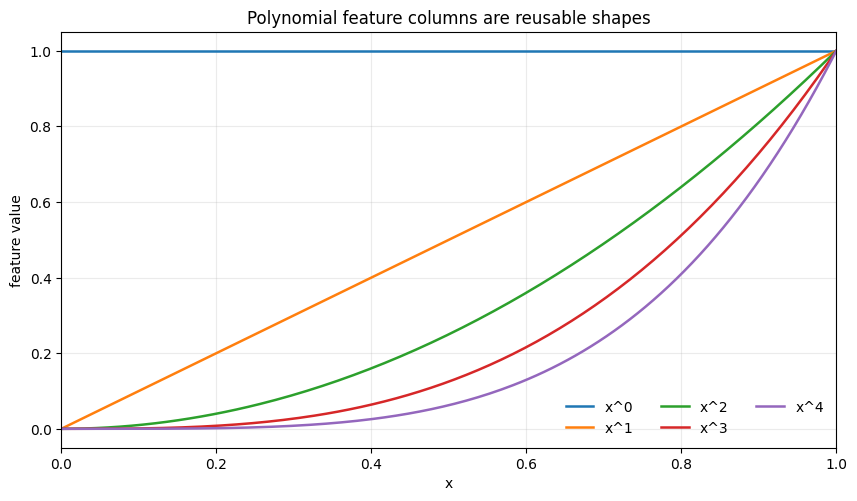

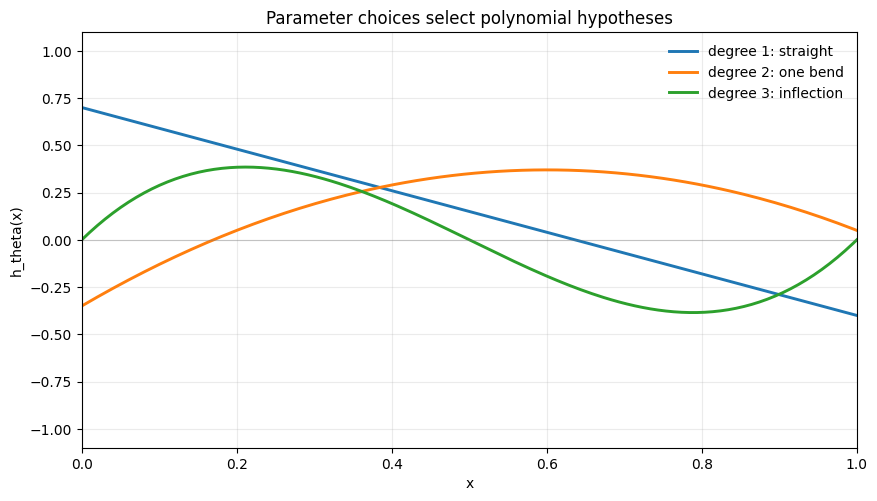

In [4]:
# Inspect Phi, choose theta, and compute Phi @ theta.
degree_preview = 4
x_preview = x_observed[:5]
Phi_preview = models.polynomial_features(x_preview, degree=degree_preview)
theta_preview = np.array([0.25, -0.60, 1.20, 0.00, -0.80])
preview_predictions = Phi_preview @ theta_preview

feature_rows = []
for x_value, row, prediction in zip(x_preview, Phi_preview, preview_predictions):
    feature_rows.append(
        {"x": x_value, **{f"x^{power}": row[power] for power in range(degree_preview + 1)}, "Phi@theta": prediction}
    )

print_rows(feature_rows, digits=4, title="First rows of Phi, with one chosen theta")
print_rows(
    [{"feature_column": f"x^{power}", "theta": theta_value} for power, theta_value in enumerate(theta_preview)],
    digits=4,
    title="Mixing weights theta",
)

x_shape_grid = data.make_test_grid(n_points=200)
Phi_shape_grid = models.polynomial_features(x_shape_grid, degree=degree_preview)
fig, ax = plt.subplots(figsize=(10.0, 5.4))
for power in range(degree_preview + 1):
    ax.plot(x_shape_grid, Phi_shape_grid[:, power], linewidth=1.8, label=f"x^{power}")
ax.set_title("Polynomial feature columns are reusable shapes")
ax.set_xlabel("x")
ax.set_ylabel("feature value")
ax.set_xlim(0.0, 1.0)
ax.grid(alpha=0.25)
ax.legend(frameon=False, ncol=3)
show_fig(fig)

example_hypotheses = [
    ("degree 1: straight", np.array([0.70, -1.10])),
    ("degree 2: one bend", np.array([-0.35, 2.40, -2.00])),
    ("degree 3: inflection", np.array([0.00, 4.00, -12.00, 8.00])),
]

fig, ax = plt.subplots(figsize=(10.0, 5.4))
for label, theta in example_hypotheses:
    Phi_curve = models.polynomial_features(x_shape_grid, degree=len(theta) - 1)
    ax.plot(x_shape_grid, Phi_curve @ theta, linewidth=2.1, label=label)
ax.axhline(0.0, color="#777777", linewidth=0.8, alpha=0.35)
ax.set_title("Parameter choices select polynomial hypotheses")
ax.set_xlabel("x")
ax.set_ylabel("h_theta(x)")
ax.set_xlim(0.0, 1.0)
ax.set_ylim(-1.1, 1.1)
ax.grid(alpha=0.25)
ax.legend(frameon=False)
show_fig(fig)


### After running: identify the available shapes

Inspect the feature columns and the example curves.

- Which columns create vertical shift, slope, curvature, and more complex bending?
- Which behaviours are impossible if a column is missing?
- Where might these columns behave badly outside observed support?

**Repack.** A feature map is a hypothesis-space design choice. It decides what kinds of functions can be built before fitting begins.


The table shows a small part of $\Phi$: rows are observations and columns are reusable shapes. The final column is the prediction created by one chosen set of weights, $\Phi\theta$.

The example curves in the second plot are:

$$
h_1(x)=0.70-1.10x,
$$

$$
h_2(x)=-0.35+2.40x-2.00x^2,
$$

$$
h_3(x)=4.00x-12.00x^2+8.00x^3.
$$

The first plot shows the raw feature columns. The second plot shows selected hypotheses built by mixing those columns. With only $1$ and $x$, every selected function is a straight line. Adding $x^2$ makes one bend available. Adding $x^3$ makes an inflection pattern available.

This is the hypothesis-space decision in miniature. More columns can make useful behaviours available, but they also add behaviours that may track measurement noise or behave strangely where the data provide weak support. Notebook 01 showed where support is weak; here we see how $\mathcal{H}$ determines what can happen in those unsupported regions.

> **Discuss.** Before fitting, which behaviours seem easy to build from these columns, and where might this representation struggle to explain the observed pattern?


## Select One Candidate by Hand

After defining the space, select one candidate from it. Before letting an optimiser choose the parameters, choose the mixing weights yourself and rerun the cell.

### Before running: distinguish $\theta$ from $\mathcal{H}$

Changing `manual_theta` changes one selected function inside the current hypothesis space. Changing `manual_degree` changes the feature map and therefore the hypothesis space itself.

Use this table as you experiment:

| Edit | What changed? | Which part of the frame changed? |
|---|---|---|
| Change one coefficient | | |
| Add a coefficient by increasing degree | | |
| Change the dataset settings | | |



Manual parameter choice
01. feature=x^0, theta=0
02. feature=x^1, theta=3.0000
03. feature=x^2, theta=-2.0000
04. feature=x^3, theta=-1.0000
What this theta produces on the observed data
01. quantity=Phi shape on D, value=(20, 4)
02. quantity=theta shape, value=(4,)
03. quantity=train MSE for this theta, value=0.9438


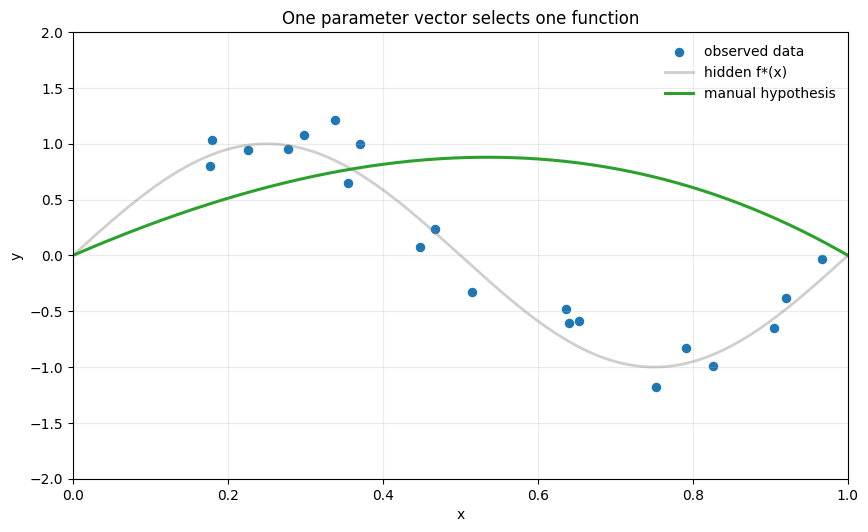

In [5]:
# Manual parameter exploration. Edit theta and rerun.
manual_degree = 3
manual_theta = np.array([0.0, 3.0, -2.0, -1.0])  # theta_0, theta_1, ..., theta_degree

if len(manual_theta) != manual_degree + 1:
    raise ValueError("manual_theta must have manual_degree + 1 entries")

x_grid = data.make_test_grid(n_points=500)
Phi_grid_manual = models.polynomial_features(x_grid, degree=manual_degree)
manual_curve = Phi_grid_manual @ manual_theta
Phi_observed_manual = models.polynomial_features(x_observed, degree=manual_degree)
manual_train_predictions = Phi_observed_manual @ manual_theta

print_rows(
    [{"feature": f"x^{power}", "theta": theta_value} for power, theta_value in enumerate(manual_theta)],
    title="Manual parameter choice",
)
print_rows(
    [
        {"quantity": "Phi shape on D", "value": str(Phi_observed_manual.shape)},
        {"quantity": "theta shape", "value": str(manual_theta.shape)},
        {"quantity": "train MSE for this theta", "value": metrics.mse(y_observed, manual_train_predictions)},
    ],
    title="What this theta produces on the observed data",
)

fig, ax = plt.subplots(figsize=(10.0, 5.8))
ax.scatter(x_observed, y_observed, s=34, color="#1f77b4", label="observed data")
ax.plot(x_grid, data.true_function(x_grid), color="#777777", alpha=0.35, linewidth=2.0, label="hidden f*(x)")
ax.plot(x_grid, manual_curve, color="#2ca02c", linewidth=2.2, label="manual hypothesis")
ax.set_title("One parameter vector selects one function")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_xlim(0.0, 1.0)
ax.set_ylim(-2.0, 2.0)
ax.grid(alpha=0.25)
ax.legend(frameon=False)
show_fig(fig)


## Separate $\mathcal{H}$ From the Selected $s$

### Anchor distinction

The hypothesis space is the menu of possible functions. A parameter vector is one order from that menu. The optimiser will later automate the selection, but it cannot order something that is not on the menu.

The manual controls above make the selection step visible. The feature map defines the available shapes, and one parameter vector $\theta$ selects one function $h_\theta$ from that space. In the workshop frame, $\mathcal{H}$ is the candidate set; $s$ is the selected solution.

In $\mathcal{H} + \mathcal{D} + \mathcal{O} \rightarrow s$ language, changing `manual_theta` changed the selected solution $s$ while the evidence $\mathcal{D}$ and hypothesis space $\mathcal{H}$ stayed fixed. Changing `manual_degree` changed $\mathcal{H}$ because it changed which polynomial functions were representable.

An optimiser will do the same kind of selection automatically: it searches the parameter space $\Theta$, chooses a value $\hat{\theta}$ according to an objective, and thereby selects the fitted hypothesis $h_{\hat{\theta}}\in\mathcal{H}$.

The important separation is:

- choosing $\phi$ and allowable $\Theta$ defines what can be represented;
- choosing a fitting objective defines which representable function is selected from the observed data.

The next section keeps $\mathcal{D}$ and the least-squares selector steady, then changes the menu itself by increasing the polynomial degree.


In [6]:
# Fit one polynomial after seeing how manual parameters behave.
degree_single = 3
coeffs_single = models.fit_polynomial_mle(x_observed, y_observed, degree=degree_single)
train_pred_single = models.predict_polynomial(x_observed, coeffs_single)

print_rows(
    [{"feature": f"x^{i}", "selected_theta": coeff} for i, coeff in enumerate(coeffs_single)],
    title=f"Selected theta values for degree {degree_single}",
)
print_rows(
    [{"degree": degree_single, "train_mse": metrics.mse(y_observed, train_pred_single), "coef_norm": metrics.coefficient_norm(coeffs_single)}],
    title="Fit summary",
)


Selected theta values for degree 3
01. feature=x^0, selected_theta=-0.6495
02. feature=x^1, selected_theta=15.4429
03. feature=x^2, selected_theta=-41.5943
04. feature=x^3, selected_theta=27.2079
Fit summary
01. degree=3, train_mse=0.0286, coef_norm=52.0505


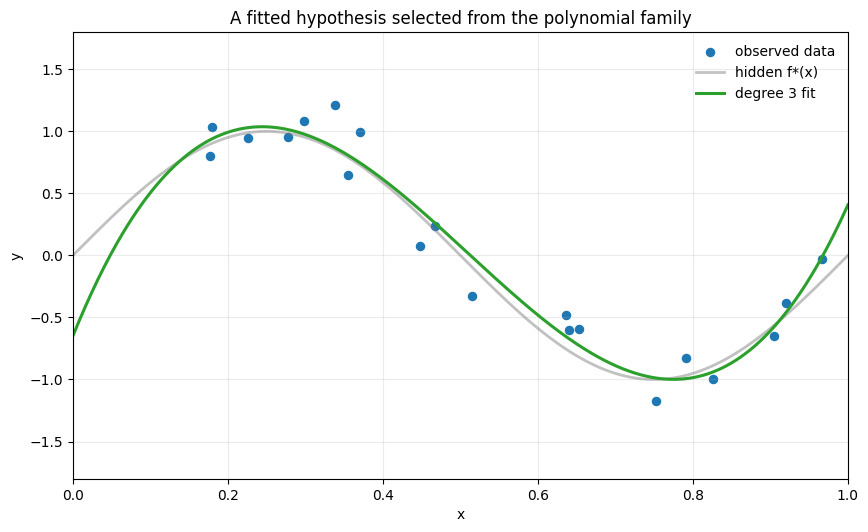

In [7]:
# Plot the fitted hypothesis against the data and the hidden function.
x_grid = data.make_test_grid(n_points=500)
y_grid_true = data.true_function(x_grid)
y_grid_single = models.predict_polynomial(x_grid, coeffs_single)

fig, ax = plt.subplots(figsize=(10.0, 5.8))
ax.scatter(x_observed, y_observed, s=34, color="#1f77b4", label="observed data")
ax.plot(x_grid, y_grid_true, color="#777777", alpha=0.45, linewidth=2.0, label="hidden f*(x)")
ax.plot(x_grid, y_grid_single, color="#2ca02c", linewidth=2.2, label=f"degree {degree_single} fit")
ax.set_title("A fitted hypothesis selected from the polynomial family")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_xlim(0.0, 1.0)
ax.set_ylim(-1.8, 1.8)
ax.grid(alpha=0.25)
ax.legend(frameon=False)
show_fig(fig)


## Change $\mathcal{H}$ While $\mathcal{D}$ Stays Fixed

Now keep $\mathcal{D}$ fixed and change only the polynomial degree. This isolates one hypothesis-space lever: the size of the polynomial feature dictionary. The question is no longer "which $\theta$ did we pick?" but "what did this version of $\mathcal{H}$ make possible?"

The degree controls the size of the feature map and gives a family of hypothesis spaces:

$$
\mathcal{H}_d = \{x \mapsto \theta^\top \phi_d(x) \mid \theta \in \mathbb{R}^{d+1}\}.
$$

Polynomial spaces are nested. A degree-3 polynomial is available inside a degree-9 space by setting the parameters on $x^4, \ldots, x^9$ to zero. Increasing $d$ keeps earlier explanations and adds new ones.

### Before running: predict the model-complexity pattern

The next cells keep $\mathcal{D}$ and the least-squares selector fixed while changing polynomial degree. That means the active lever is $\mathcal{H}$.

Fill this table before running:

| Degree | Expected training error | Expected behaviour away from data | Reason |
|---:|---|---|---|
| 0 | | | |
| 1 | | | |
| 3 | | | |
| 9 | | | |
| 15 | | | |

The next cells compare training error, an oracle grid error for this simulation, parameter norm, conditioning, and fitted prediction range. Read these as diagnostics of what the chosen hypothesis space made possible, especially in the gaps and weakly supported regions identified in Notebook 01.


In [8]:
# Compare several hypothesis spaces on exactly the same observations.
degrees = (0, 1, 3, 9, 15)
x_grid = data.make_test_grid(n_points=500)
y_grid_true = data.true_function(x_grid)

hypothesis_rows = []
hypothesis_fits = {}

for degree in degrees:
    Phi = models.polynomial_features(x_observed, degree=degree)
    coeffs = models.fit_polynomial_mle(x_observed, y_observed, degree=degree)
    train_pred = models.predict_polynomial(x_observed, coeffs)
    grid_pred = models.predict_polynomial(x_grid, coeffs)
    hypothesis_fits[degree] = {"coeffs": coeffs, "grid_pred": grid_pred}
    hypothesis_rows.append(
        {
            "degree": degree,
            "n_features": degree + 1,
            "train_mse": metrics.mse(y_observed, train_pred),
            "oracle_grid_mse": metrics.mse(y_grid_true, grid_pred),
            "coef_norm_warning": metrics.coefficient_norm(coeffs),
            "condition_number": np.linalg.cond(Phi),
            "pred_min": np.min(grid_pred),
            "pred_max": np.max(grid_pred),
        }
    )

print_rows(hypothesis_rows, digits=4, title="Same data, different polynomial spaces")

Same data, different polynomial spaces
01. degree=0, n_features=1, train_mse=0.6068, oracle_grid_mse=0.5081, coef_norm_warning=0.0956, condition_number=1.0000, pred_min=0.0956, pred_max=0.0956
02. degree=1, n_features=2, train_mse=0.1767, oracle_grid_mse=0.2738, coef_norm_warning=2.9818, condition_number=5.1396, pred_min=-1.1012, pred_max=1.4847
03. degree=3, n_features=4, train_mse=0.0286, oracle_grid_mse=0.0193, coef_norm_warning=52.0505, condition_number=236.1409, pred_min=-0.9991, pred_max=1.0374
04. degree=9, n_features=10, train_mse=0.0171, oracle_grid_mse=181.4230, coef_norm_warning=1.68e+06, condition_number=5.96e+07, pred_min=-93.5528, pred_max=1.5079
05. degree=15, n_features=16, train_mse=0.0098, oracle_grid_mse=1.91e+07, coef_norm_warning=5.14e+11, condition_number=2.98e+13, pred_min=-3.65e+04, pred_max=125.6317


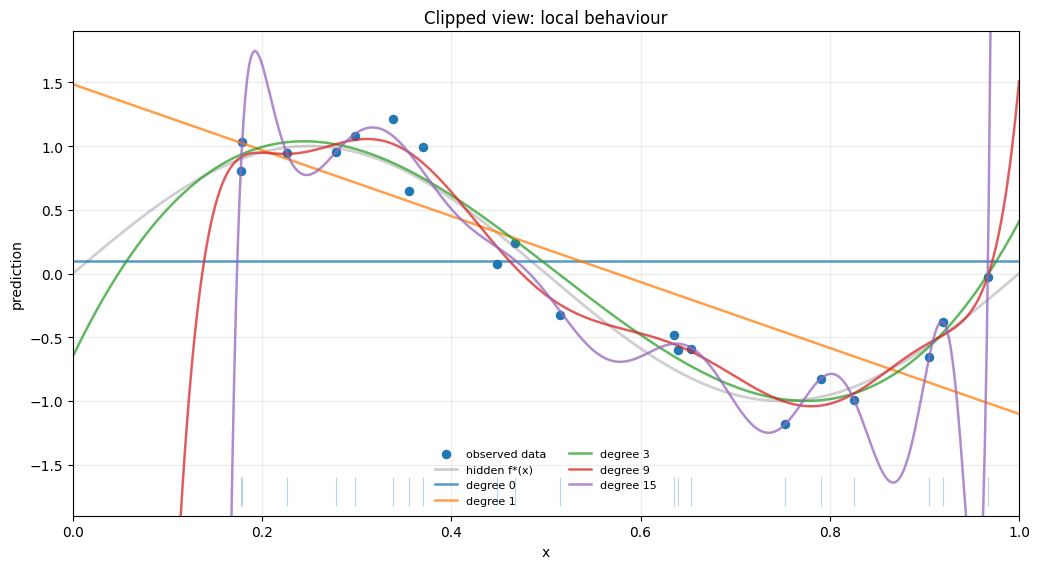

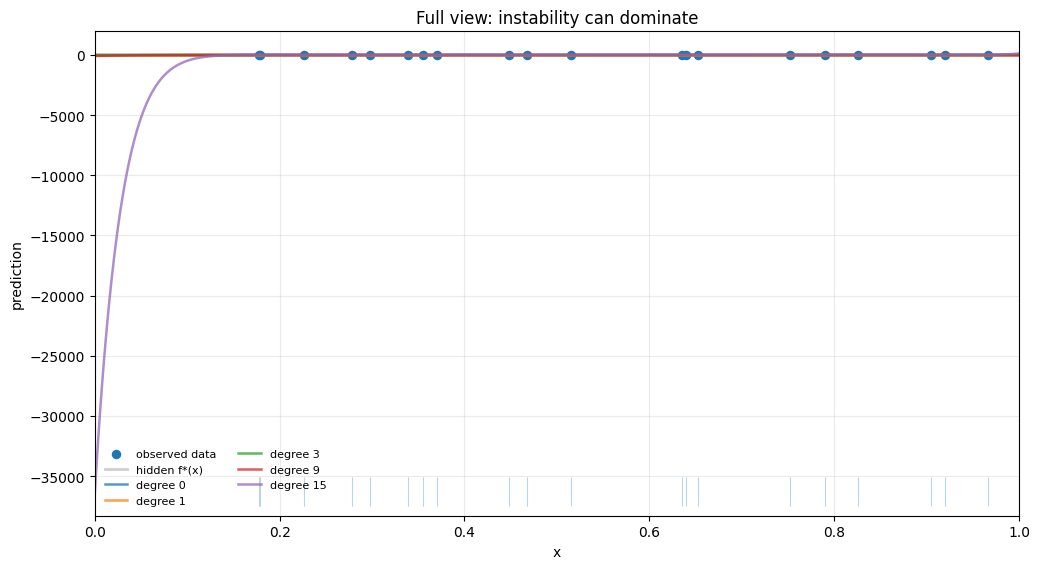

In [9]:
# Plot the selected functions after inspecting the summaries.
colors = plt.get_cmap("tab10")
view_specs = [
    {"title": "Clipped view: local behaviour", "ylim": (-1.9, 1.9)},
    {"title": "Full view: instability can dominate", "ylim": None},
]

for view in view_specs:
    fig, ax = plt.subplots(figsize=(10.5, 5.8))
    ax.scatter(x_observed, y_observed, s=34, color="#1f77b4", label="observed data")
    ax.plot(x_grid, y_grid_true, color="#777777", alpha=0.35, linewidth=2.0, label="hidden f*(x)")
    ax.vlines(x_observed, 0.02, 0.08, transform=ax.get_xaxis_transform(), color="#1f77b4", alpha=0.30, linewidth=0.8)
    for idx, degree in enumerate(degrees):
        ax.plot(
            x_grid,
            hypothesis_fits[degree]["grid_pred"],
            color=colors(idx),
            linewidth=1.8,
            label=f"degree {degree}",
            alpha=0.75,
        )
    ax.set_title(view["title"])
    ax.set_xlabel("x")
    ax.set_ylabel("prediction")
    ax.set_xlim(0.0, 1.0)
    if view["ylim"] is None:
        ax.relim()
        ax.autoscale_view()
    else:
        ax.set_ylim(*view["ylim"])
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, fontsize=8, ncol=2)
    fig.tight_layout()
    show_fig(fig)


### After running: diagnose the hypothesis-space lever

Read the comparison in terms of what was possible.

- If the degree is too low, the required shape is not available.
- If the degree is high, training rows can be matched more closely.
- If the degree is too high relative to the data, unsupported behaviours can appear between or beyond observations.

**Repack.** Increasing $\mathcal{H}$ increases what can be represented. It does not guarantee that the selected function is more defensible.

Use the table, full-view plot, and bottom ticks together. The ticks mark observed $x$-locations; large curve movement between ticks is behaviour that the data weakly constrain. The `oracle_grid_mse` column is available only because this is a simulation. In real work, use held-out data, residual checks, domain knowledge, sensitivity analysis, and the deployment region.

> **Discuss.** Which curve would you defend as a scientific explanation, what part of the table or plot makes you uneasy, and why?


## When $\mathcal{D}$ Does Not Identify One Hypothesis

The previous section showed that a rich hypothesis space can fit the observed rows while behaving strangely between them. This section explains the mechanism in plain terms: the dataset only checks the function at the inputs we measured.

If two functions make nearly the same predictions at those measured inputs, then $\mathcal{D}$ has little basis for choosing between them, even if they disagree elsewhere. A high-degree polynomial space can contain directions that change the function between observed points while barely changing predictions on the observed rows.

In matrix language, those weakly seen directions look like a non-zero vector $v$ such that

$$
\Phi v \approx 0.
$$

Adding that direction to the parameters changes the coefficients but barely changes the predictions on the observed data:

$$
\Phi(\theta + \alpha v) \approx \Phi\theta.
$$

### Advanced diagnostic: when finite data do not identify one function

Before running, predict where two such functions are most likely to diverge:

- near densely observed points;
- inside large gaps;
- outside the sampled range.

Explain your prediction using data support from Notebook 01.


Same evidence fit, different between-point behaviour
01. quantity=Phi shape, value=(20, 26)
02. quantity=rank(Phi), value=18
03. quantity=near-null directions, value=8
04. quantity=smallest singular value, value=3.24e-16
05. quantity=perturbation scale, value=4.48e+07
06. quantity=max training prediction difference, value=3.80e-07
07. quantity=max grid prediction difference, value=4.00000


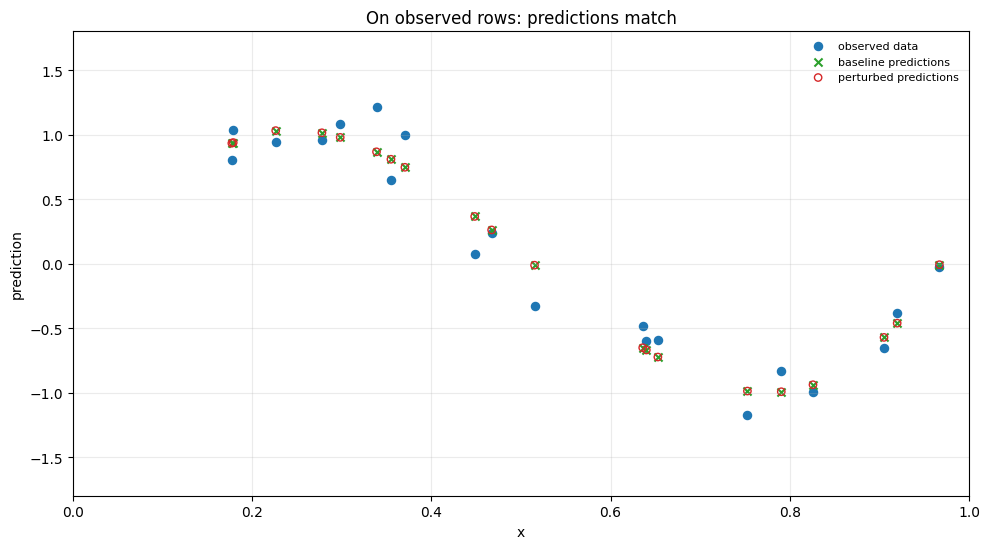

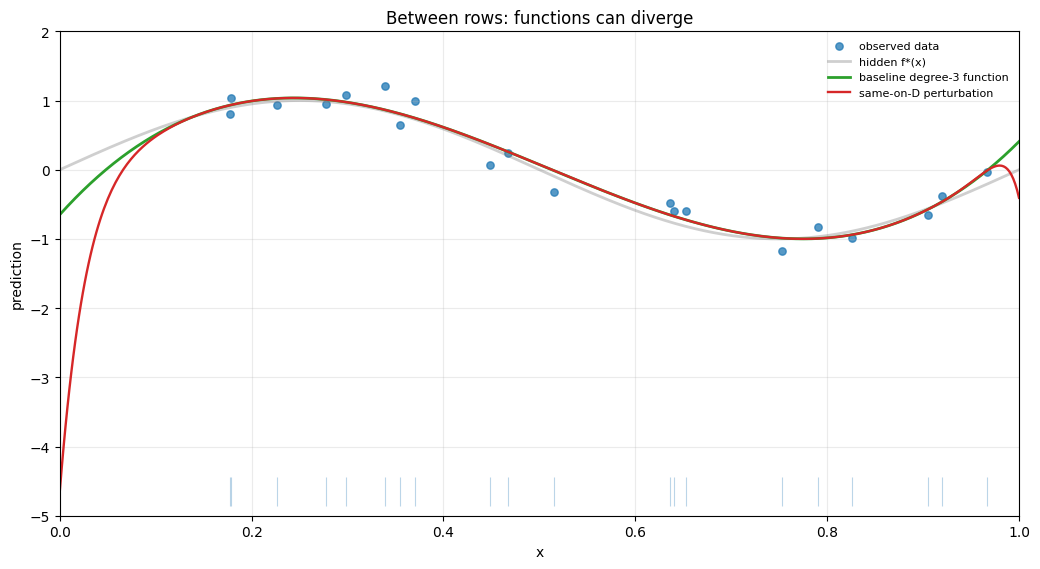

In [8]:
# Build two degree-25 parameter vectors with nearly identical training predictions
# but visibly different behaviour between observed points.
underdetermined_degree = 25
baseline_degree = 3

Phi_under = models.polynomial_features(x_observed, degree=underdetermined_degree)
base_coeffs = np.zeros(underdetermined_degree + 1)
base_coeffs[: baseline_degree + 1] = models.fit_polynomial_mle(
    x_observed,
    y_observed,
    degree=baseline_degree,
)

# Find a direction that the observed rows of Phi barely see.
_, singular_values, vh = np.linalg.svd(Phi_under, full_matrices=True)
rank_under = np.linalg.matrix_rank(Phi_under)
null_basis = vh[rank_under:]

x_grid = data.make_test_grid(n_points=500)
Phi_grid_under = models.polynomial_features(x_grid, degree=underdetermined_degree)
grid_null_effects = Phi_grid_under @ null_basis.T
null_grid_amplitudes = np.max(np.abs(grid_null_effects), axis=0)
selected_null_index = int(np.argmax(null_grid_amplitudes))
null_direction = null_basis[selected_null_index]

# Scale the direction so the between-point behaviour is visible while training predictions remain matched.
target_grid_difference = 4.0
unit_grid_difference = np.max(np.abs(Phi_grid_under @ null_direction))
perturbation_scale = target_grid_difference / unit_grid_difference
perturbed_coeffs = base_coeffs + perturbation_scale * null_direction

train_pred_base = Phi_under @ base_coeffs
train_pred_perturbed = Phi_under @ perturbed_coeffs
grid_pred_base = Phi_grid_under @ base_coeffs
grid_pred_perturbed = Phi_grid_under @ perturbed_coeffs

print_rows(
    [
        {"quantity": "Phi shape", "value": str(Phi_under.shape)},
        {"quantity": "rank(Phi)", "value": rank_under},
        {"quantity": "near-null directions", "value": len(null_basis)},
        {"quantity": "smallest singular value", "value": singular_values[-1]},
        {"quantity": "perturbation scale", "value": perturbation_scale},
        {"quantity": "max training prediction difference", "value": np.max(np.abs(train_pred_base - train_pred_perturbed))},
        {"quantity": "max grid prediction difference", "value": np.max(np.abs(grid_pred_base - grid_pred_perturbed))},
    ],
    digits=5,
    title="Same evidence fit, different between-point behaviour",
)

fig_train, ax_train = plt.subplots(figsize=(10.0, 5.6))
ax_train.scatter(x_observed, y_observed, s=34, color="#1f77b4", label="observed data")
ax_train.scatter(x_observed, train_pred_base, s=34, color="#2ca02c", marker="x", label="baseline predictions")
ax_train.scatter(x_observed, train_pred_perturbed, s=28, color="#d62728", marker="o", facecolors="none", label="perturbed predictions")
ax_train.set_title("On observed rows: predictions match")
ax_train.set_xlabel("x")
ax_train.set_ylabel("prediction")
ax_train.set_xlim(0.0, 1.0)
ax_train.set_ylim(-1.8, 1.8)
ax_train.grid(alpha=0.25)
ax_train.legend(frameon=False, fontsize=8)
fig_train.tight_layout()
show_fig(fig_train)

fig_grid, ax_grid = plt.subplots(figsize=(10.5, 5.8))
ax_grid.scatter(x_observed, y_observed, s=28, color="#1f77b4", alpha=0.75, label="observed data")
ax_grid.plot(x_grid, data.true_function(x_grid), color="#777777", alpha=0.35, linewidth=2.0, label="hidden f*(x)")
ax_grid.vlines(x_observed, 0.02, 0.08, transform=ax_grid.get_xaxis_transform(), color="#1f77b4", alpha=0.30, linewidth=0.8)
ax_grid.plot(x_grid, grid_pred_base, color="#2ca02c", linewidth=2.0, label="baseline degree-3 function")
ax_grid.plot(x_grid, grid_pred_perturbed, color="#d62728", linewidth=1.7, label="same-on-D perturbation")
ax_grid.set_title("Between rows: functions can diverge")
ax_grid.set_xlabel("x")
ax_grid.set_ylabel("prediction")
ax_grid.set_xlim(0.0, 1.0)
ax_grid.set_ylim(-5.0, 2.0)
ax_grid.grid(alpha=0.25)
ax_grid.legend(frameon=False, fontsize=8)
fig_grid.tight_layout()
show_fig(fig_grid)


### After running: connect underdetermination to support

The left panel checks the training rows: the two parameter vectors give almost identical predictions where $\mathcal{D}$ has observations. The right panel shows the catch: the same two vectors can define different functions between those observations. The bottom ticks mark the observed $x$-locations so the unsupported intervals from Notebook 01 are visible again.

This is the finite-data version of non-identifiability. The dataset may constrain predictions at sampled inputs while leaving some representable behaviours weakly constrained elsewhere. The problem is not simply "too many parameters"; it is the combination of a rich $\mathcal{H}$ and a finite, unevenly informative $\mathcal{D}$.

**Repack.** A rich $\mathcal{H}$ plus finite $\mathcal{D}$ can leave several explanations compatible with the observed data. Later, $\mathcal{O}$ will decide which compatible explanation is selected.

> **Discuss.** When two parameter vectors explain the observed points equally well, what extra assumptions or checks would make one selected curve more defensible than another?


## Separate Function Space From Coordinates

### Advanced checkpoint: functions versus coordinates

This section separates two ideas that often get conflated.

- The **function space** is the set of curves that can be represented.
- The **coordinate system** is how we describe and search that set numerically.

Changing feature coordinates does not always change the hypothesis space. A degree-$d$ polynomial function can be represented using raw monomials $1,x,x^2,\ldots$ or using shifted Chebyshev polynomials on $[0,1]$. Both coordinate systems span the same degree-limited polynomial functions.

Two coordinate systems can describe the same $\mathcal{H}$ but produce different coefficient magnitudes, condition numbers, and numerical sensitivity. This matters because a numerical problem can look like a modelling problem if we do not separate them.

The next cell makes this concrete. First inspect the columns as shapes. Then compare the condition numbers of the two feature matrices on the observed data.

The handoff to Notebook 03 is now visible: once hypotheses are represented in coordinates, an objective and algorithm have to search those coordinates. Notebook 02 asks what functions are possible; Notebook 03 asks what rule selects one of them.


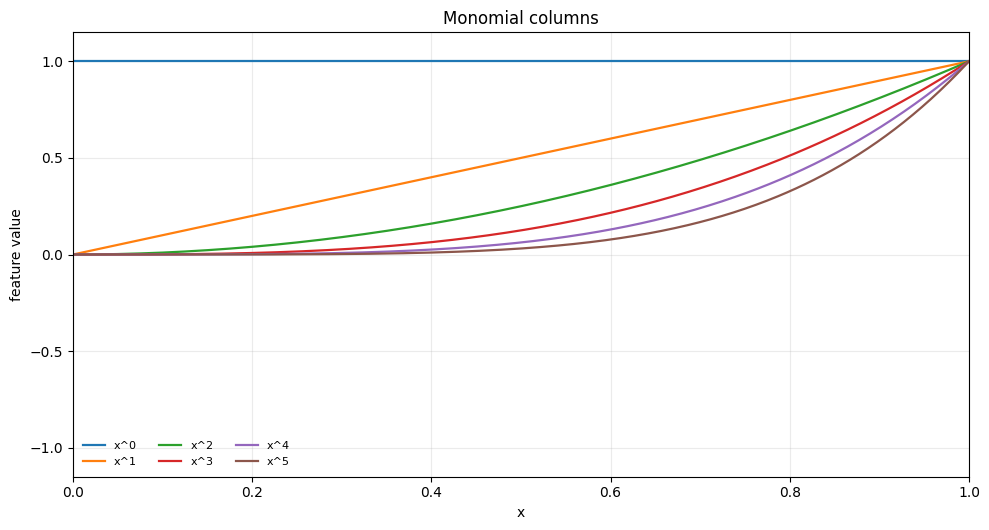

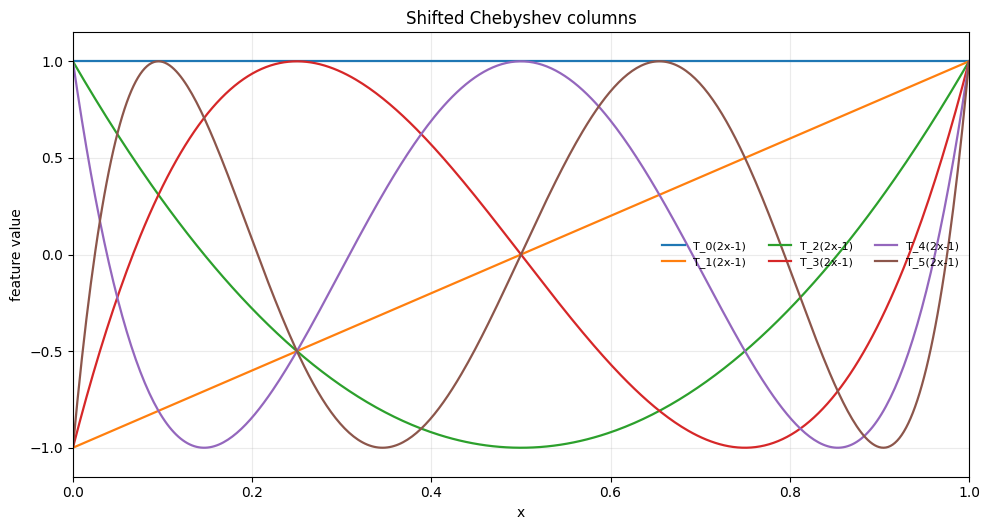

Same polynomial space, different conditioning
01. feature_coordinates=monomial powers, condition_number=2.98e+13
02. feature_coordinates=shifted Chebyshev, condition_number=7.13e+05


In [7]:
# Compare two coordinate systems for the same degree-limited polynomial space.
conditioning_degree = 15
visual_degree = 5

x_grid = data.make_test_grid(n_points=400)
x_shifted_grid = 2.0 * x_grid - 1.0
Phi_monomial_visual = models.polynomial_features(x_grid, degree=visual_degree)
Phi_chebyshev_visual = np.polynomial.chebyshev.chebvander(x_shifted_grid, deg=visual_degree)

coordinate_views = [
    ("Monomial columns", Phi_monomial_visual, lambda degree: f"x^{degree}"),
    ("Shifted Chebyshev columns", Phi_chebyshev_visual, lambda degree: f"T_{degree}(2x-1)"),
]

for title, feature_matrix, labeler in coordinate_views:
    fig, ax = plt.subplots(figsize=(10.0, 5.4))
    for degree in range(visual_degree + 1):
        ax.plot(x_grid, feature_matrix[:, degree], linewidth=1.6, label=labeler(degree))
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("feature value")
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(-1.15, 1.15)
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, fontsize=8, ncol=3)
    fig.tight_layout()
    show_fig(fig)

x_shifted = 2.0 * x_observed - 1.0
Phi_monomial = models.polynomial_features(x_observed, degree=conditioning_degree)
Phi_chebyshev = np.polynomial.chebyshev.chebvander(x_shifted, deg=conditioning_degree)

print_rows(
    [
        {"feature_coordinates": "monomial powers", "condition_number": np.linalg.cond(Phi_monomial)},
        {"feature_coordinates": "shifted Chebyshev", "condition_number": np.linalg.cond(Phi_chebyshev)},
    ],
    digits=4,
    title="Same polynomial space, different conditioning",
)


## Summary: What $\mathcal{H}$ Adds and What It Cannot Decide

Read the examples as one diagnostic sequence for $\mathcal{H}$.

1. **Feature columns define available shapes.** The feature map decides what kinds of explanations can be built. A low-degree model may leave a visible pattern unexplained because the needed shape is not available inside the hypothesis space.

2. **Approximation error is a hypothesis-space limitation.** For the noise-free regression function, approximation error is the gap between $f^*(x)$ and the best function inside $\mathcal{H}$ over the region we care about:

   $$
   h^*_{\mathcal{H}} = \arg\min_{h \in \mathcal{H}} \mathbb{E}_{x\sim P_{\mathcal{X}}}\left[(h(x)-f^*(x))^2\right].
   $$

   If the target is a future noisy measurement rather than the hidden signal, expected risk also includes irreducible noise. That separates the shape limitation of $\mathcal{H}$ from randomness in the measurements.

3. **Larger spaces trade underfitting for fragility.** A high-degree model can drive training error down while its behaviour between observations and beyond observed support becomes hard to defend.

4. **Finite data may not identify one explanation.** The null-space example shows why: two parameter vectors can make nearly identical predictions on $\mathcal{D}$ while defining different functions between observed rows.

5. **Selection pressure comes next.** If several hypotheses fit the observed data well, the data alone have not chosen among them. The objective, regularisation, numerical convention, or extra evidence determines which member of $\mathcal{H}$ is selected.

6. **Coordinates are not the same as functions.** Some fragility comes from the size of $\mathcal{H}$, and some comes from the coordinates used to represent it. Chebyshev coordinates can describe the same polynomial space with a very different condition number from monomial coordinates.

The `oracle_grid_mse` column is a teaching diagnostic available only because this notebook simulates the hidden signal. It compares each fitted curve with $f^*$ on a dense grid. In real work, $f^*$ is hidden, so the practical substitutes are held-out data, residual analysis, domain checks, sensitivity analysis, and scientific judgement.

> **Discuss.** Which selected curve would you trust outside the observed points, and what assumption makes that trust reasonable?


## Bridge to Notebook 03

Notebook 01 asked what evidence was available: what was recorded, where it was recorded, how noisy it was, and where it left gaps. Notebook 02 asked what explanations were possible: what shapes were available, which functions could be selected, and which behaviours remained underdetermined by that same finite evidence.

That still leaves one ingredient unresolved. A hypothesis space contains candidates; it does not choose among them. Notebook 03 keeps $\mathcal{D}$ and $\mathcal{H}$ visible, then studies $\mathcal{O}$: the losses, penalties, and selection rules that turn available candidates into one selected solution $s$.


## References

- Bishop, C. M. (2006). [*Pattern Recognition and Machine Learning*](https://link.springer.com/book/9780387310732). Polynomial curve fitting, linear basis-function models, model complexity, and overfitting.
- Trefethen, L. N. (2019). [*Approximation Theory and Approximation Practice, Extended Edition*](https://epubs.siam.org/doi/10.1137/1.9781611975949). Polynomial approximation, Chebyshev approximation, and Runge-type instability.
- Trefethen, L. N., & Bau, D., III. (1997). [*Numerical Linear Algebra*](https://epubs.siam.org/doi/10.1137/1.9780898719574). Rank, null spaces, singular values, least squares, and conditioning.


## 📝 Hypothesis Space Diagnostic Lessons Summary

This notebook explored **$\mathcal{H}$ (the hypothesis space)**, the menu of possible explanations.

1.  **The Menu of Explanations**: $\mathcal{H}$ defines the set of functions the learner is allowed to consider. If the truth is not in $\mathcal{H}$, the learner can never find it.
2.  **Model Flexibility**: Increasing the "capacity" (e.g., polynomial degree) expands $\mathcal{H}$. A larger space can represent more complex patterns but also becomes more sensitive to noise.
3.  **Numerical Stability**: Coordinate choices (like Chebyshev vs. Monomials) affect the solver's ability to navigate $\mathcal{H}$ reliably, even if they represent the same space of functions.
4.  **Identifiability**: If $\mathcal{H}$ is too large relative to the data ($P > n$), there are infinitely many "perfect" theories that fit the data but disagree wildly in the gaps.
5.  **Room to Wiggle**: Without enough data to "pin down" a flexible model, the hypothesis space remains full of contradictory but data-consistent explanations.
